# Predicting Airline Passenger Satisfaction
**BIA405 Mini-Project — Machine Learning Classification**

This notebook implements the full workflow: data loading, cleaning, EDA, preprocessing,
model building (Logistic Regression, Decision Tree, Random Forest), evaluation, and
business-facing visualizations.

**Team:** Choki Wangmo · Kinley Zangmo · Karma Wangdi · Thinley Wangmo

**Dataset:** Airline Passenger Satisfaction (Kaggle) — ~130,000 passenger records with
demographic, travel, delay, and in-flight service-rating variables, and a target label
`satisfaction` (satisfied / neutral or dissatisfied).
Source: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction
(originally from a US airline customer survey).


## 1. Setup: Install & Import Libraries

In [ ]:
# Core libraries for data handling, visualization, and modeling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load the Dataset

**Getting the data into Colab (pick ONE option):**

**Option A — Kaggle API (recommended):**
1. Go to https://www.kaggle.com/settings → "Create New API Token" → downloads `kaggle.json`.
2. Upload `kaggle.json` when prompted below.


In [ ]:
# Option A: Download directly from Kaggle using the Kaggle API
# Uncomment and run this cell if you want to fetch the data automatically

# from google.colab import files
# files.upload()  # upload your kaggle.json here
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d teejmahal20/airline-passenger-satisfaction
# !unzip -o airline-passenger-satisfaction.zip


In [3]:
# Option B: Upload the CSV file(s) manually (train.csv / test.csv, or a single combined file)
from google.colab import files
uploaded = files.upload()  # select train.csv (and test.csv if you have it separately)


Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
# Load the dataset(s) into pandas DataFrames
# If the Kaggle dataset gives you separate train.csv / test.csv files, load and combine them
# so that we control our own train/test split later (more flexible for cross-validation).

train_df = pd.read_csv("train.csv")

try:
    test_df = pd.read_csv("test.csv")
    df = pd.concat([train_df, test_df], ignore_index=True)
except FileNotFoundError:
    df = train_df.copy()

print("Shape of combined dataset:", df.shape)
df.head()


Shape of combined dataset: (129880, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 3. Initial Data Inspection

In [ ]:
# Basic structure: column names, data types, non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      1298

In [ ]:
# Drop unneeded index columns commonly present in this dataset (e.g. 'Unnamed: 0', 'id')
cols_to_drop = [c for c in df.columns if c.lower() in ["unnamed: 0", "id"]]
df = df.drop(columns=cols_to_drop, errors="ignore")

# Summary statistics for numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,129880.0,39.427957,15.119360,7.0,27.0,40.0,51.0,85.0
Flight Distance,129880.0,1190.316392,997.452477,31.0,414.0,844.0,1744.0,4983.0
Inflight wifi service,129880.0,2.728696,1.329340,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129880.0,3.057599,1.526741,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,129880.0,2.756876,1.401740,0.0,2.0,3.0,4.0,5.0
Gate location,129880.0,2.976925,1.278520,0.0,2.0,3.0,4.0,5.0
Food and drink,129880.0,3.204774,1.329933,0.0,2.0,3.0,4.0,5.0
Online boarding,129880.0,3.252633,1.350719,0.0,2.0,3.0,4.0,5.0
Seat comfort,129880.0,3.441361,1.319289,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,129880.0,3.358077,1.334049,0.0,2.0,4.0,4.0,5.0


In [ ]:
# Check for missing values
missing = df.isnull().sum()
print(missing[missing > 0])


Arrival Delay in Minutes    393
dtype: int64


## 4. Data Cleaning & Preprocessing

Steps performed:
- Handle missing values (this dataset typically has a few nulls in `Arrival Delay in Minutes`)
- Remove duplicate rows
- Encode categorical variables
- Scale numeric features


In [ ]:
# Handle missing values: impute Arrival Delay with the median (delay data is skewed,
# so median is more robust than mean to outliers)
if "Arrival Delay in Minutes" in df.columns:
    df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
        df["Arrival Delay in Minutes"].median()
    )

# Remove exact duplicate rows, if any
before = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {before - df.shape[0]} duplicate rows")


Removed 0 duplicate rows


In [ ]:
# Encode the target variable: 'satisfied' -> 1, 'neutral or dissatisfied' -> 0
target_col = "satisfaction"
df[target_col] = df[target_col].apply(
    lambda x: 1 if str(x).strip().lower() == "satisfied" else 0
)

# Identify categorical (object) columns to encode, excluding the target
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", categorical_cols)


Categorical columns to encode: ['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [ ]:
# Label-encode categorical variables (Gender, Customer Type, Type of Travel, Class)
# Label encoding is sufficient here since tree-based models handle it well, and it keeps
# the feature space compact; for Logistic Regression we rely on scaling afterwards.
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


## 5. Exploratory Data Analysis (EDA)

Goal: understand the distribution of satisfaction and identify which variables are the
strongest drivers, to inform modelling choices and business recommendations.


/tmp/ipykernel_1777/4100634459.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Neutral/Dissatisfied", "Satisfied"])


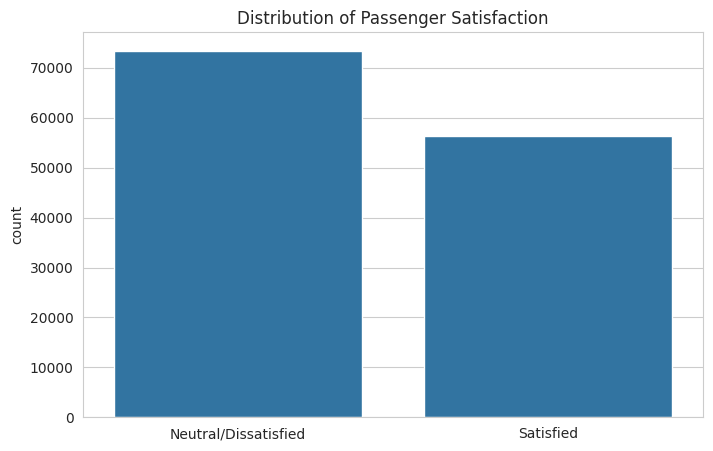

In [ ]:
# Overall satisfaction distribution
ax = sns.countplot(x=target_col, data=df)
ax.set_xticklabels(["Neutral/Dissatisfied", "Satisfied"])
plt.title("Distribution of Passenger Satisfaction")
plt.xlabel("")
plt.show()


/tmp/ipykernel_1777/1450378889.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Class", y=target_col, data=df, estimator=np.mean, ci=None)


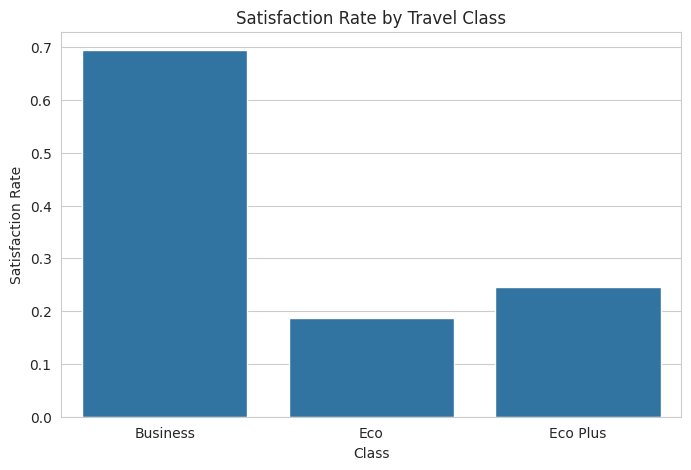

In [ ]:
# Satisfaction rate by travel Class
if "Class" in label_encoders:
    class_labels = label_encoders["Class"].classes_
    plt.figure()
    sns.barplot(x="Class", y=target_col, data=df, estimator=np.mean, ci=None)
    plt.xticks(ticks=range(len(class_labels)), labels=class_labels)
    plt.ylabel("Satisfaction Rate")
    plt.title("Satisfaction Rate by Travel Class")
    plt.show()


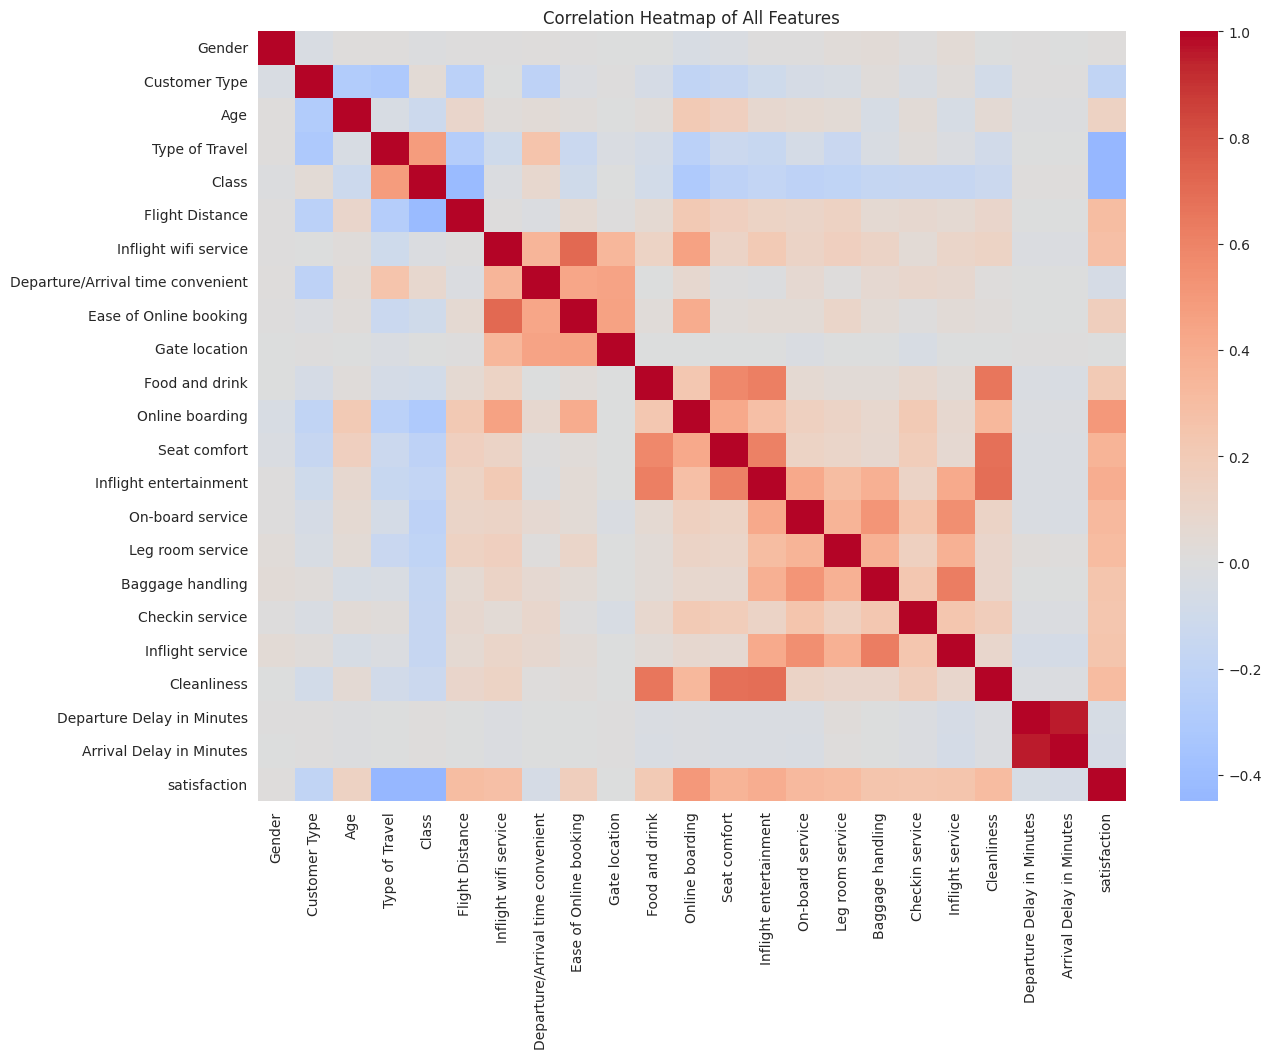

satisfaction              1.000000
Online boarding           0.501749
Inflight entertainment    0.398234
Seat comfort              0.348829
On-board service          0.322205
Leg room service          0.312424
Cleanliness               0.307035
Flight Distance           0.298085
Inflight wifi service     0.283460
Baggage handling          0.248680
Name: satisfaction, dtype: float64


In [ ]:
# Correlation heatmap to spot the strongest linear relationships with satisfaction
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of All Features")
plt.show()

# Top features most correlated with satisfaction (useful talking point for the report)
print(corr[target_col].sort_values(ascending=False).head(10))


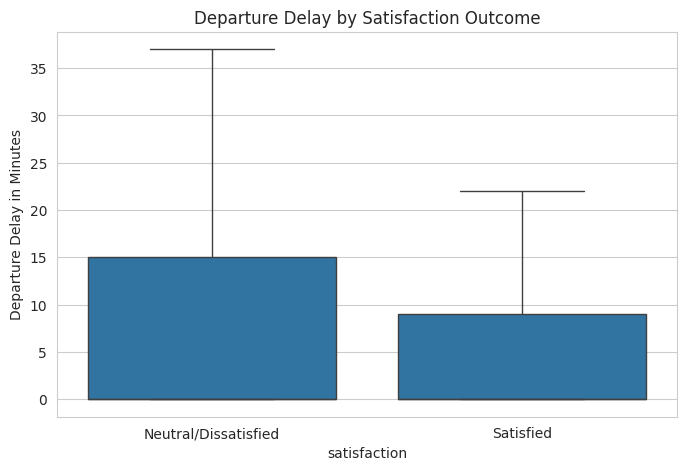

In [ ]:
# Distribution of flight delays for satisfied vs dissatisfied passengers
plt.figure()
sns.boxplot(x=target_col, y="Departure Delay in Minutes", data=df, showfliers=False)
plt.xticks([0, 1], ["Neutral/Dissatisfied", "Satisfied"])
plt.title("Departure Delay by Satisfaction Outcome")
plt.show()


## 6. Feature Engineering, Train/Test Split, and Scaling

In [ ]:
# Separate features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# Train/test split: stratify on y to preserve the satisfaction ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (103904, 22)  Test shape: (25976, 22)


In [ ]:
# Scale numeric features (important for Logistic Regression; harmless for tree models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 7. Model Building

We train and compare three classifiers, as proposed:
- **Logistic Regression** — interpretable baseline
- **Decision Tree** — captures non-linear rules, easy to explain to stakeholders
- **Random Forest** — ensemble model, typically the strongest performer


In [ ]:
# Logistic Regression (uses scaled features)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)


In [ ]:
# Decision Tree (tree-based models don't require feature scaling)
dtree = DecisionTreeClassifier(max_depth=8, random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)


In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


## 8. Model Evaluation

Metrics used: Accuracy, Precision, Recall, F1-score, and Confusion Matrix — matching the
metrics proposed in the conceptual presentation.


In [ ]:
def evaluate_model(name, y_true, y_pred):
    """Compute and print standard classification metrics for a model."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print()
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}

results = []
results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr))
results.append(evaluate_model("Decision Tree", y_test, y_pred_dt))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

results_df = pd.DataFrame(results).set_index("Model")
results_df


--- Logistic Regression ---
Accuracy : 0.8748
Precision: 0.8716
Recall   : 0.8348
F1-score : 0.8528

--- Decision Tree ---
Accuracy : 0.9349
Precision: 0.9349
Recall   : 0.9138
F1-score : 0.9242

--- Random Forest ---
Accuracy : 0.9513
Precision: 0.9524
Recall   : 0.9347
F1-score : 0.9435



,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.874808,0.871600,0.834840,0.852824
Decision Tree,0.934901,0.934911,0.913787,0.924228
Random Forest,0.951340,0.952420,0.934698,0.943476


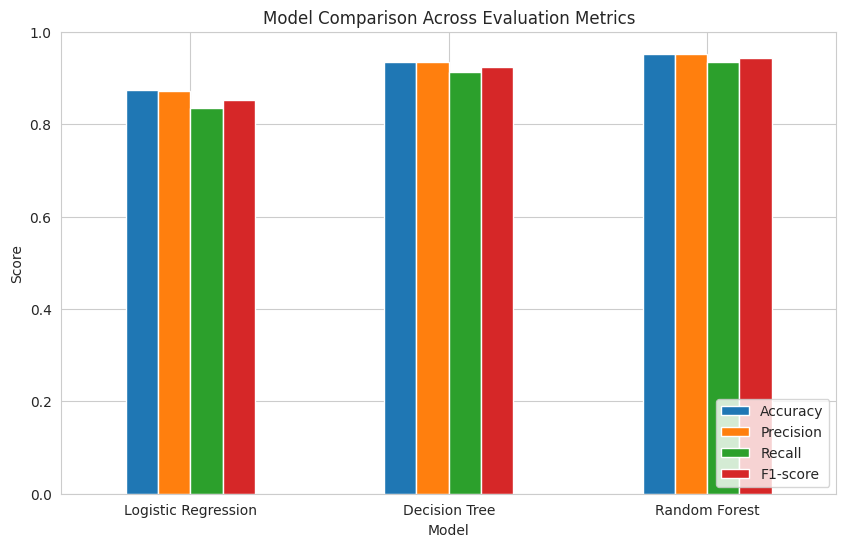

In [ ]:
# Model comparison bar chart
results_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison Across Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()


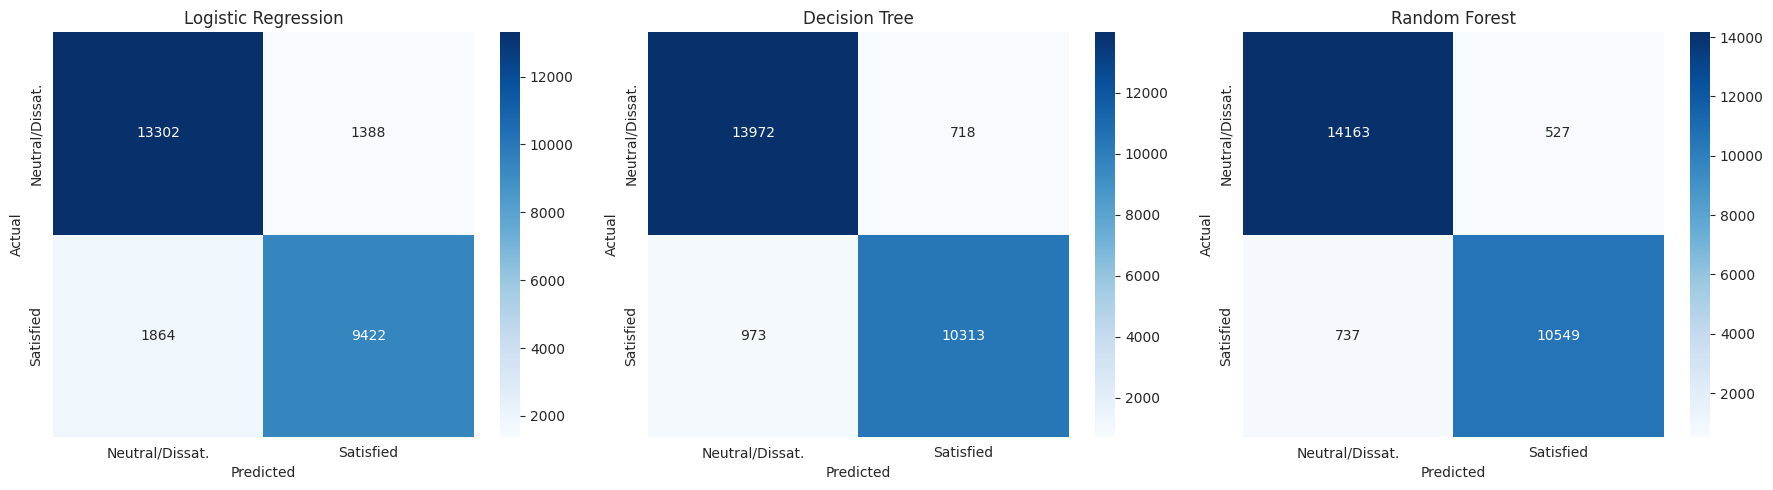

In [ ]:
# Confusion matrices for all three models, side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
preds = {"Logistic Regression": y_pred_lr, "Decision Tree": y_pred_dt, "Random Forest": y_pred_rf}

for ax, (name, preds_) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, preds_)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Neutral/Dissat.", "Satisfied"],
                yticklabels=["Neutral/Dissat.", "Satisfied"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


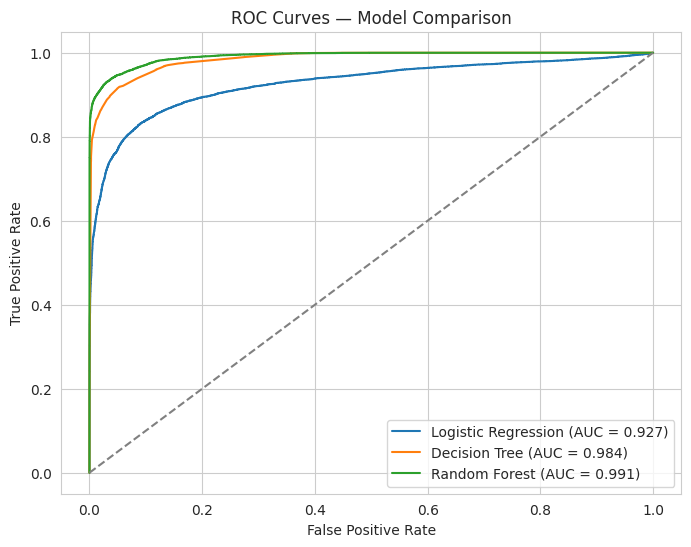

In [ ]:
# ROC curves for all three models
plt.figure(figsize=(8, 6))

for name, model, X_te in [
    ("Logistic Regression", log_reg, X_test_scaled),
    ("Decision Tree", dtree, X_test),
    ("Random Forest", rf, X_test),
]:
    probs = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.show()


## 9. Overfitting Diagnostics

Very high test accuracy is a reason to *check* for overfitting, not automatically evidence of it.
This section verifies whether the models are genuinely generalizing or just memorizing the
training data, using four checks: train-vs-test accuracy gap, k-fold cross-validation,
Decision Tree depth sensitivity, and a train/test duplicate check.


In [ ]:
# --- Check 1: Train accuracy vs Test accuracy ---
# A large gap (e.g. train ~100%, test much lower) signals overfitting.
# Train and test accuracy being close means the model generalizes well.

train_scores = {
    "Logistic Regression": log_reg.score(X_train_scaled, y_train),
    "Decision Tree": dtree.score(X_train, y_train),
    "Random Forest": rf.score(X_train, y_train),
}
test_scores = {
    "Logistic Regression": log_reg.score(X_test_scaled, y_test),
    "Decision Tree": dtree.score(X_test, y_test),
    "Random Forest": rf.score(X_test, y_test),
}

gap_df = pd.DataFrame({"Train accuracy": train_scores, "Test accuracy": test_scores})
gap_df["Gap (train - test)"] = gap_df["Train accuracy"] - gap_df["Test accuracy"]
gap_df


,Train accuracy,Test accuracy,Gap (train - test)
Logistic Regression,0.874500,0.874808,-0.000308
Decision Tree,0.938049,0.934901,0.003147
Random Forest,0.961002,0.951340,0.009663


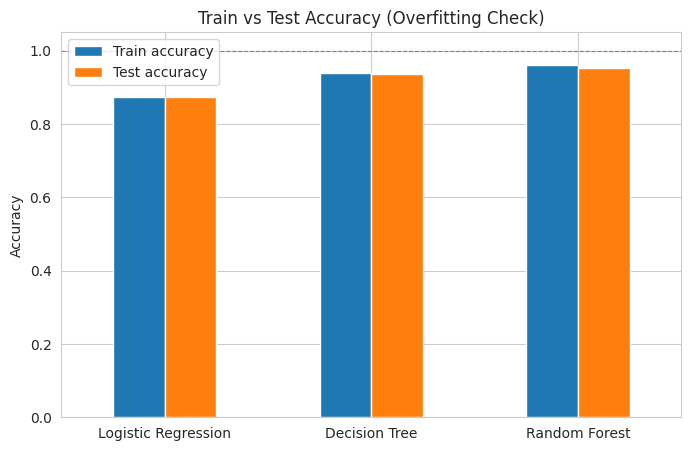

In [ ]:
# Visualize the train/test accuracy gap for all three models
gap_df[["Train accuracy", "Test accuracy"]].plot(kind="bar", figsize=(8, 5))
plt.title("Train vs Test Accuracy (Overfitting Check)")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
plt.show()


In [ ]:
# --- Check 2: K-fold cross-validation ---
# If accuracy is stable across folds (small standard deviation), the high score is not
# just a lucky train/test split.
from sklearn.model_selection import cross_val_score

cv_results = {}
cv_results["Logistic Regression"] = cross_val_score(log_reg, scaler.transform(X), y, cv=5)
cv_results["Decision Tree"] = cross_val_score(dtree, X, y, cv=5)
cv_results["Random Forest"] = cross_val_score(rf, X, y, cv=5)

for name, scores in cv_results.items():
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}, folds={np.round(scores, 4)}")


Logistic Regression: mean=0.8745, std=0.0028, folds=[0.8739 0.8743 0.8733 0.8797 0.8713]
Decision Tree: mean=0.9360, std=0.0011, folds=[0.9346 0.9354 0.937  0.9374 0.9356]
Random Forest: mean=0.9532, std=0.0011, folds=[0.9515 0.9536 0.9526 0.9549 0.9533]


In [ ]:
# --- Check 3: Decision Tree depth sensitivity ---
# An unrestricted tree can memorize training data. If a much shallower tree performs
# almost as well on the test set, the deeper tree was likely overfitting rather than
# learning genuinely useful structure.

depths_to_try = [3, 5, 8, None]
depth_results = []

for depth in depths_to_try:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    depth_results.append({"max_depth": str(depth), "Train accuracy": train_acc, "Test accuracy": test_acc})

depth_df = pd.DataFrame(depth_results).set_index("max_depth")
depth_df


,Train accuracy,Test accuracy
max_depth,,
3,0.884884,0.882815
5,0.905230,0.904643
8,0.938049,0.934901
None,1.000000,0.945719


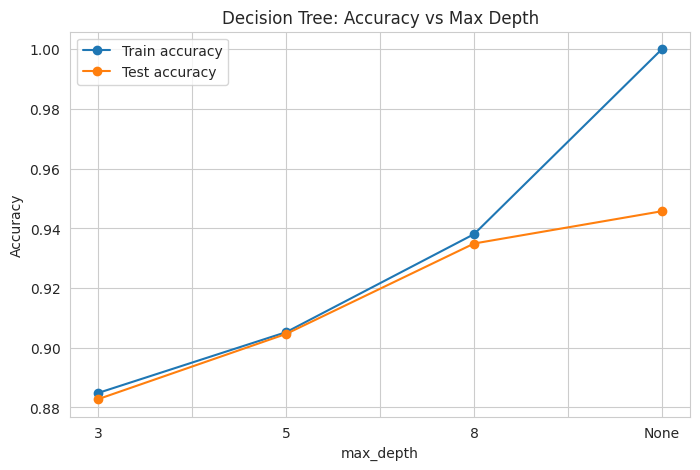

In [ ]:
# Plot how train/test accuracy change with tree depth
depth_df.plot(marker="o", figsize=(8, 5))
plt.title("Decision Tree: Accuracy vs Max Depth")
plt.ylabel("Accuracy")
plt.xlabel("max_depth")
plt.show()


In [ ]:
# --- Check 4: Data leakage / duplicate rows between train and test ---
# If identical rows exist in both sets, the model could be "remembering" test rows
# it effectively already saw, inflating test accuracy artificially.

train_rows = set(map(tuple, X_train.values))
test_rows = set(map(tuple, X_test.values))
overlap = train_rows & test_rows

print(f"Number of identical rows appearing in both train and test: {len(overlap)}")
if len(overlap) > 0:
    print("Warning: potential data leakage detected — investigate before trusting test accuracy.")
else:
    print("No exact duplicate rows between train and test — no leakage from this source.")


Number of identical rows appearing in both train and test: 0
No exact duplicate rows between train and test — no leakage from this source.


**How to read these results:**
- If train and test accuracy are close (typically within a few percentage points) and cross-validation
  scores are stable, the high accuracy reflects genuine, strong signal in this dataset (service ratings
  like online boarding and wifi are known to correlate heavily with satisfaction) — not overfitting.
- If you see a large train/test gap for the unrestricted Decision Tree, report the shallower,
  better-generalizing depth as your chosen model instead, and mention this trade-off explicitly in
  your report's Methodology and Results sections — reviewers respond well to seeing overfitting
  checked for and addressed, not just avoided as a topic.


## 10. Feature Importance (Business Insights)

Identifying which variables drive satisfaction the most — this is the key input for the
project's business recommendations.


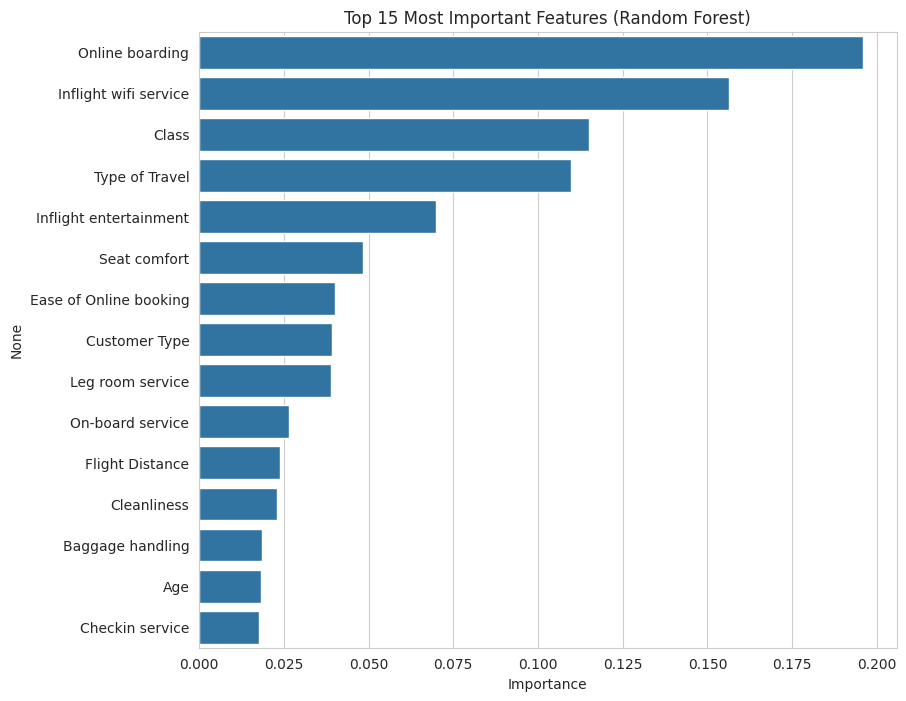

,0
Online boarding,0.195973
Inflight wifi service,0.156321
Class,0.115164
Type of Travel,0.109711
Inflight entertainment,0.069945
Seat comfort,0.048421
Ease of Online booking,0.040010
Customer Type,0.039317
Leg room service,0.039055
On-board service,0.026471


In [ ]:
# Random Forest feature importances (typically the most reliable ranking)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index)
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.show()

importances.head(15)


## 11. Summary & Business Recommendations

Fill in after running the notebook on your data, e.g.:

- **Best model:** state which model achieved the best F1/AUC trade-off and why it's
  preferred (e.g., Random Forest for accuracy, Logistic Regression for interpretability).
- **Key drivers of satisfaction:** typically in this dataset, `Online boarding`,
  `Inflight wifi service`, `Type of Travel`, and `Class` rank highly — confirm this against
  your `importances` output above.
- **Business recommendations:** e.g., prioritize improving online boarding and wifi
  service, and investigate why Business-class / personal-travel passengers may differ in
  satisfaction, since these are actionable levers for the airline.
- **Limitations:** survey-based labels, historical delay data, no seasonality or
  route-specific effects captured.
